In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
r=1.55 #logistic映射参数
N=500 #格子大小

In [3]:
# 1. 离散化区间 [-1, 1]
edges = np.linspace(-1, 1, N + 1)
centers = (edges[:-1] + edges[1:]) / 2

In [4]:
# 2. 构造转移矩阵 P (Perron-Frobenius 算子的离散近似)
P = np.zeros((N, N))

In [5]:
# 对每个格子中心点进行映射，看它落到哪个新格子
for j in range(N):
    x_next = 1 - r * (centers[j]**2) #映射值
    # 找到落在哪个 bin (利用 searchsorted 快速定位)
    i = np.searchsorted(edges, x_next) - 1 #顺序数第几个格子
    P[i, j] = 1.0  # 确定性映射
    #print(i,j,1)

In [6]:
# 3. 计算特征值
eigenvalues = np.linalg.eigvals(P)
eigenvalues[0:10]

array([-1.00000000e+00+0.j       , -8.66025404e-01+0.5j      ,
       -8.66025404e-01-0.5j      , -5.00000000e-01+0.8660254j,
       -5.00000000e-01-0.8660254j,  5.55111512e-17+1.j       ,
        5.55111512e-17-1.j       ,  5.00000000e-01+0.8660254j,
        5.00000000e-01-0.8660254j,  1.00000000e+00+0.j       ])

In [7]:
# 取模长，并排序
mags = np.sort(np.abs(eigenvalues))

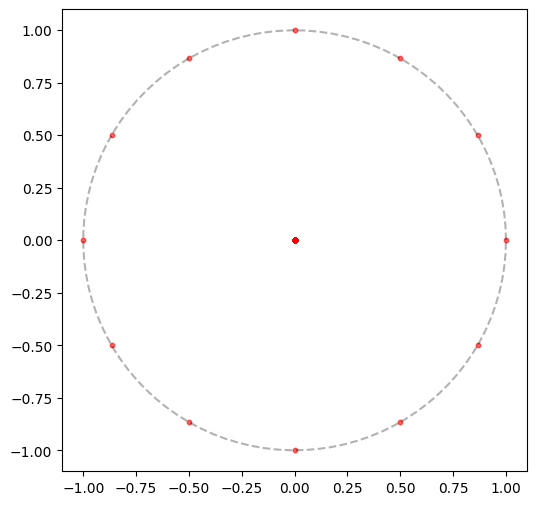

In [8]:
# 4. 绘图
plt.figure(figsize=(6, 6))
# 画出单位圆
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3)

# 画出特征值分布
plt.scatter(eigenvalues.real, eigenvalues.imag, s=10, c='red', alpha=0.6)